<a href="https://colab.research.google.com/github/fvillena/biocompu/blob/2024/labs/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 5

In [2]:
import tensorflow as tf # Biblioteca de redes neuronales
import pandas as pd # # Biblioteca de manejo de conjuntos de datos
import sklearn.preprocessing # Preprocesamiento de datos
import sklearn.model_selection # # Funciones para preparar nuestro conjunto de datos
import sklearn.metrics # Métricas
import matplotlib.pyplot as plt # Biblioteca de visualización
import numpy as np # Biblioteca de álgebra lineal
import scipy.stats
import os
import PIL
import datetime

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/fvillena/biocompu/2024/data/wisconsin.csv")

1. Verifique y preprocese si es necesario las características.

In [4]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,B,13.540,14.36,87.46,566.3,9.779,8.129,6.664,4.781,1.885,...,15.110,19.26,99.70,711.2,144.000,1.773,239.000,1.288,2.977,7.259
1,B,13.080,15.71,85.63,520.0,1.075,127.000,4.568,311.000,1.967,...,14.500,20.49,96.09,630.5,1.312,2.776,189.000,7.283,3.184,8.183
2,B,9.504,12.44,60.34,273.9,1.024,6.492,2.956,2.076,1.815,...,10.230,15.66,65.13,314.9,1.324,1.148,8.867,6.227,245.000,7.773
3,B,13.030,18.42,82.61,523.8,8.983,3.766,2.562,2.923,1.467,...,13.300,22.81,84.46,545.9,9.701,4.619,4.833,5.013,1.987,6.169
4,B,8.196,16.84,51.71,201.9,86.000,5.943,1.588,5.917,1.769,...,8.964,21.96,57.26,242.2,1.297,1.357,688.000,2.564,3.105,7.409


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [7]:
features = data.iloc[:,1:]

label = data.diagnosis

In [9]:
features.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,13.540,14.36,87.46,566.3,9.779,8.129,6.664,4.781,1.885,5.766,...,15.110,19.26,99.70,711.2,144.000,1.773,239.000,1.288,2.977,7.259
1,13.080,15.71,85.63,520.0,1.075,127.000,4.568,311.000,1.967,6.811,...,14.500,20.49,96.09,630.5,1.312,2.776,189.000,7.283,3.184,8.183
2,9.504,12.44,60.34,273.9,1.024,6.492,2.956,2.076,1.815,6.905,...,10.230,15.66,65.13,314.9,1.324,1.148,8.867,6.227,245.000,7.773
3,13.030,18.42,82.61,523.8,8.983,3.766,2.562,2.923,1.467,5.863,...,13.300,22.81,84.46,545.9,9.701,4.619,4.833,5.013,1.987,6.169
4,8.196,16.84,51.71,201.9,86.000,5.943,1.588,5.917,1.769,6.503,...,8.964,21.96,57.26,242.2,1.297,1.357,688.000,2.564,3.105,7.409


In [11]:
label.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

Escalamos nuestras características utilizando un Min-Max Scaler.

In [12]:
scaler = sklearn.preprocessing.MinMaxScaler()
features_scaled = scaler.fit_transform(features)

Nuestras etiquetas son discretas, por lo que las transformamos con un codificador One-Hot

In [13]:
encoder = sklearn.preprocessing.LabelEncoder() # Label encoder de sklearn que mapea las categorías a números enteros
label_encoded = encoder.fit_transform(label)
label_encoded = tf.keras.utils.to_categorical(label_encoded) # Implementación de Tensorflow del One-Hot Encoding

In [14]:
label_encoded

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

2. Separe el conjunto de datos en un subconjunto de entrenamiento y prueba

In [15]:
features_train, features_test, label_train, label_test = sklearn.model_selection.train_test_split(
    features_scaled,
    label_encoded,
    test_size=0.2,
    random_state=11
)
features_train, features_val, label_train, label_val = sklearn.model_selection.train_test_split(
    features_train,
    label_train,
    test_size=0.1,
    random_state=11
)

In [16]:
features_train.shape

(409, 30)

3. Diseñe una red neuronal artificial del tipo Totalmente Conectada que resuelva la tarea.

In [54]:
model = tf.keras.Sequential([ # Este objeto recibe una lista de capas.
    tf.keras.layers.Dense(128, activation='relu'), # Capa densa de 12 neuronas con una activación ReLU
    tf.keras.layers.Dense(len(encoder.classes_), activation='softmax') # Capa densa de clasificación
                                                                       # con una activación Softmax
                                                                       # la cantidad de neuronas de esta capa
                                                                       # debe ser igual a la cantidad de clases
])

Configuramos el modelo para el entrenamiento

In [55]:
model.compile(optimizer='adam', # Utilizamos un optimizador ADAM
              loss='binary_crossentropy', # Utilizamos una función de pérdida de entropía cruzada binaria
              metrics=['accuracy']) # Medimos el rendimiento del modelo con la exactitud

In [56]:
early_stopping = tf.keras.callbacks.EarlyStopping( # Instanciamos un objeto de Early Stopping para detener el entrenamiento si no seguimos aprendiendo
    monitor='val_accuracy', # Monitoreamos el accuracy del conjunto de validación
    patience=3, # Si por 3 épocas seguidas no aumentamos el accuracy, detenemos el entrenamiento
    restore_best_weights=True, # Cuando detenemos el entrenamiento restablecemos los pesos con el mejor rendimiento.
    verbose=True
)

4. Entrene la red neuronal artificial con los datos del subconjunto de entrenamiento.

In [57]:
history = model.fit( # Guardamos el historial del modelo
          features_scaled,
          label_encoded,
          epochs=20, # Detenemos el entrenamiento al llegar a 20 épocas
          callbacks=[early_stopping], # Llamamos a nuestro objeto de Early Stopping al final de cada época
          validation_data=(features_val,label_val) # Al final de cada época probamos el rendimiento en el conjunto de validación
          )

Epoch 1/20
18/18 [==============================] - 1s 13ms/step - loss: 0.6810 - accuracy: 0.6555 - val_loss: 0.6678 - val_accuracy: 0.6957
Epoch 2/20
18/18 [==============================] - 0s 5ms/step - loss: 0.6437 - accuracy: 0.7838 - val_loss: 0.6366 - val_accuracy: 0.7826
Epoch 3/20
18/18 [==============================] - 0s 5ms/step - loss: 0.6029 - accuracy: 0.8137 - val_loss: 0.6049 - val_accuracy: 0.7609
Epoch 4/20
18/18 [==============================] - 0s 6ms/step - loss: 0.5565 - accuracy: 0.8436 - val_loss: 0.5636 - val_accuracy: 0.8043
Epoch 5/20
18/18 [==============================] - 0s 5ms/step - loss: 0.5054 - accuracy: 0.8612 - val_loss: 0.5270 - val_accuracy: 0.8043
Epoch 6/20
18/18 [==============================] - 0s 5ms/step - loss: 0.4559 - accuracy: 0.8594 - val_loss: 0.4914 - val_accuracy: 0.8261
Epoch 7/20
18/18 [==============================] - 0s 6ms/step - loss: 0.4106 - accuracy: 0.8682 - val_loss: 0.4587 - val_accuracy: 0.8261
Epoch 8/20
18/18 [=

Visualizamos el rendimiento de nuestro modelo al avanzar las épocas.

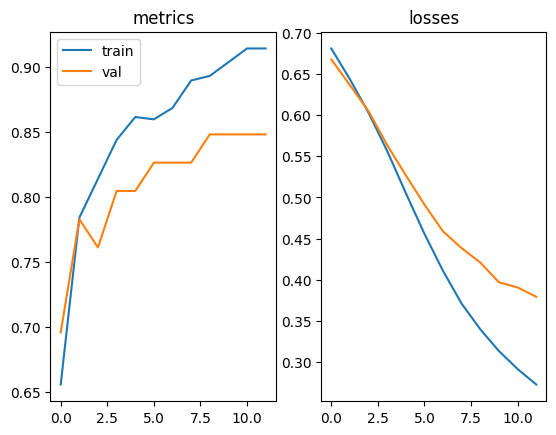

In [58]:
fig, axs = plt.subplots(1,2)
axs[0].plot(
    history.history["accuracy"],
    label="train"
)
axs[0].plot(
    history.history["val_accuracy"],
    label="val"
)
axs[0].set_title("metrics")
axs[1].plot(
    history.history["loss"]
)
axs[1].plot(
    history.history["val_loss"]
)
axs[1].set_title("losses")
axs[0].legend()

5. Prediga sobre el subconjunto de prueba utilizando la red neuronal artificial
ajustada.

In [59]:
predictions = model.predict(features_test)

4/4 [==============================] - 0s 2ms/step


6. Calcule al menos dos métricas de rendimiento para el modelo.

In [60]:
print(sklearn.metrics.classification_report(
    label_test.argmax(axis=1), # Utilizamos argmax para obtener la etiqueta de cada punto de datos
    predictions.argmax(axis=1)
))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        75
           1       0.97      0.82      0.89        39

    accuracy                           0.93       114
   macro avg       0.94      0.90      0.92       114
weighted avg       0.93      0.93      0.93       114

